# 05 · Starting from pre-formed sinograms

**Audience:** users who already have sinograms — e.g. from MIDAS's own
PF-HEDM pipeline (`findSingleSolutionPFRefactored` produces per-grain
sinograms in `Sinos/`), or from any other source where the
dark/white normalisation has already happened.

**Goal:** demonstrate `run_tomo_from_sinos()` and confirm that the
same cleanup tuning workflow applies to sinogram input.

**Key difference vs. raw input:** with `areSinos=1` MIDAS skips dark/
white normalisation and just reconstructs. Stripe removal still
works on sinogram input.


In [1]:
# --- Setup ---------------------------------------------------------
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make the MIDAS TOMO Python API importable
MIDAS_TOMO = os.path.expanduser('~/opt/MIDAS/TOMO')
if MIDAS_TOMO not in sys.path:
    sys.path.insert(0, MIDAS_TOMO)
NB_DIR = os.path.join(MIDAS_TOMO, 'notebooks')
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

import _phantom as phantom

# Working directory for this notebook's outputs
WORK = os.path.expanduser('~/tomo_notebooks/05_sinos')
os.makedirs(WORK, exist_ok=True)
print('Working dir:', WORK)


Working dir: /Users/hsharma/tomo_notebooks/05_sinos


## 1 · Generate (or load) sinograms directly

The phantom helper has a `make_sinograms_only` function that emits a
`(n_slices, n_thetas, det_xdim)` float32 array — the layout
`run_tomo_from_sinos()` expects for a multi-slice stack.


In [2]:
vol = phantom.make_phantom(64, 64, 64)
angles = np.arange(0, 180, 1.0, dtype=np.float32)
sinos = phantom.make_sinograms_only(vol, angles, add_rings=True)
print('sinograms:', sinos.shape, sinos.dtype)


sinograms: (64, 180, 64) float32


## 2 · Look at one sinogram

Vertical streaks at a few detector columns are visible — they will
become rings if we skip stripe removal.


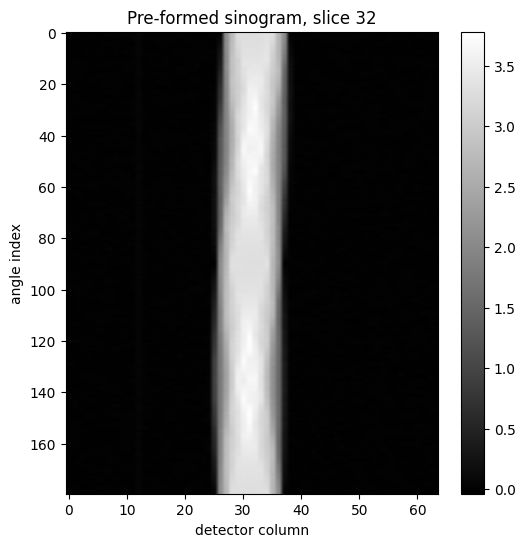

In [3]:
sl = sinos.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(sinos[sl], aspect='auto', cmap='gray')
plt.xlabel('detector column'); plt.ylabel('angle index')
plt.title(f'Pre-formed sinogram, slice {sl}')
plt.colorbar(); plt.show()


## 3 · Reconstruct via `run_tomo_from_sinos()`

`doLog=0` because the input is already in `-ln(transmission)` units
(the absorption coefficient × path length). `doLog=1` would take an
additional log.


In [4]:
from midas_tomo_python import run_tomo_from_sinos
recon_sinos = run_tomo_from_sinos(
    sinos, WORK, angles,
    shifts=0.0, doLog=0, numCPUs=4, doCleanup=1,
)
cube = recon_sinos[0]
print('recon:', cube.shape)


Time elapsed in preprocessing: 0.023s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 41342 processes.
We will us

## 4 · Baseline vs cleanup tuning on sinogram input

The cleanup sweep API works on sinogram input too — just pass the
`areSinos=1`-style data via the standard `run_tomo_cleanup_sweep`
wrapper. Under the hood it routes through the same `stripeConfigFile`
mechanism.

For sinograms, you can also handcraft a sweep by calling `run_tomo_from_sinos`
once per config — useful when the workflow is already in sinogram
space (e.g. PF-HEDM intermediate outputs):


In [5]:
grid = [
    {'snr': 0.0, 'la': 0,  'sm': 0},
    {'snr': 3.0, 'la': 15, 'sm': 5},
    {'snr': 3.0, 'la': 21, 'sm': 7},
    {'snr': 1.5, 'la': 21, 'sm': 7},
]
cubes = []
for cfg in grid:
    if cfg['snr'] > 0:
        r = run_tomo_from_sinos(sinos, WORK, angles, shifts=0.0,
                                doLog=0, numCPUs=4, doCleanup=1,
                                doStripeRemoval=1, stripeSnr=cfg['snr'],
                                stripeLaSize=cfg['la'], stripeSmSize=cfg['sm'])
    else:
        r = run_tomo_from_sinos(sinos, WORK, angles, shifts=0.0,
                                doLog=0, numCPUs=4, doCleanup=1)
    cubes.append(r[0])


Time elapsed in preprocessing: 0.023s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 41342 processes.
We will us

Time elapsed in preprocessing: 0.023s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes (snr=3.0, la=15, sm=5)

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 413

Time elapsed in preprocessing: 0.023s.


Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes (snr=3.0, la=21, sm=7)

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 41342 processes.
We will use 6 MB RAM.
Tot

Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes (snr=1.5, la=21, sm=7)

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 41342 processes.
We will use 6 MB RAM.
Tot

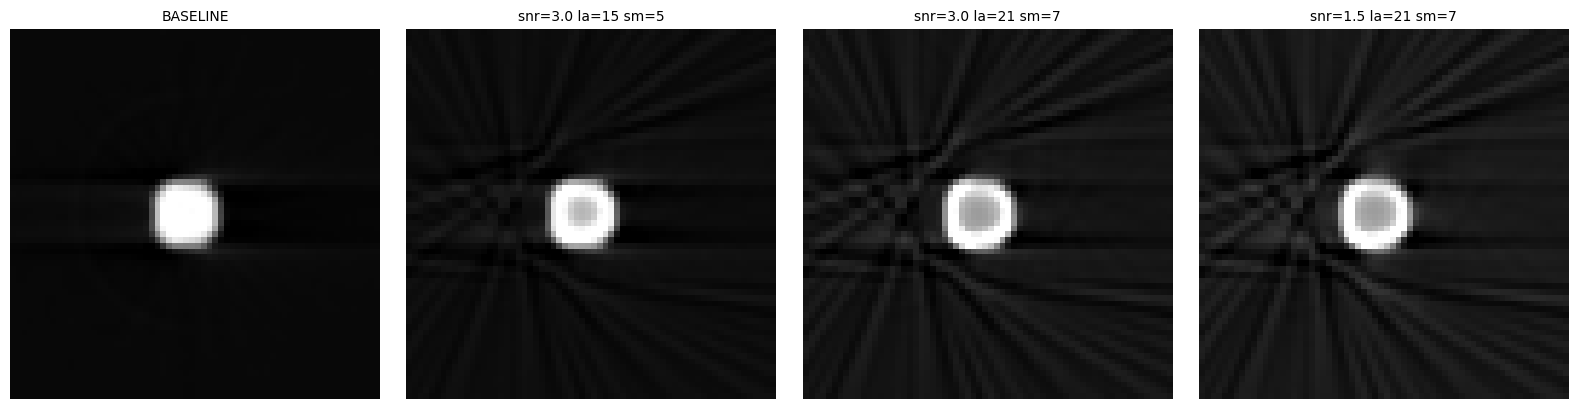

In [6]:
sl = cubes[0].shape[0] // 2
fig, axes = plt.subplots(1, len(grid), figsize=(4 * len(grid), 4))
for ax, cube, cfg in zip(axes, cubes, grid):
    im = cube[sl]
    vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
    ax.imshow(im, cmap='gray', vmin=vmin, vmax=vmax)
    title = (f'snr={cfg["snr"]} la={cfg["la"]} sm={cfg["sm"]}'
             if cfg['snr'] > 0 else 'BASELINE')
    ax.set_title(title, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()


## 5 · Single-slice sinogram input

`run_tomo_from_sinos` accepts a 2-D `(n_thetas, det_xdim)` array for a
single slice — handy when looking at one grain at a time in PF-HEDM:


Time elapsed in preprocessing: 0.001s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 2

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/05_sinos/input_sino.bin
    Input Type      : Sinograms
    Recon Output    : /Users/hsharma/tomo_notebooks/05_sinos/output
  Detector:
    Dimensions      : 64 x 2 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 2
    Auto Centering  : Yes
    Log Projection  : No
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1662138, Total available RAM: 68719476736, MaxNProcs: 41344.
We can run up to 41342 processes.
We will use 6

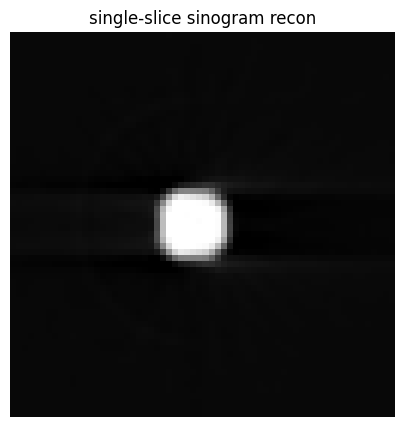

In [7]:
one_sino = sinos[sl]   # (n_thetas, det_xdim)
r = run_tomo_from_sinos(one_sino, WORK, angles, shifts=0.0,
                        doLog=0, numCPUs=4, doCleanup=1)
print('single-slice recon:', r.shape)   # (1, 1, X, Y)
plt.figure(figsize=(5, 5))
im = r[0, 0]
vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
plt.imshow(im, cmap='gray', vmin=vmin, vmax=vmax)
plt.title('single-slice sinogram recon')
plt.axis('off'); plt.show()


## 6 · Connecting to PF-HEDM

The PF-HEDM pipeline writes per-grain sinograms into a `Sinos/`
folder with filenames like `sino_raw_grNr_NNNN.tif`. The recipe is:

```python
import tifffile
sino = tifffile.imread('Sinos/sino_raw_grNr_0000.tif').T  # (theta, x)
thetas = np.loadtxt('Thetas/thetas_grNr_0000.txt')

recon = run_tomo_from_sinos(
    sino, 'Tomo/', thetas, shifts=0.0,
    filterNr=2, doLog=0, numCPUs=1)
```

`pfIntensityViewer.py` does exactly this for every grain at startup —
see the manual §3.4 for the wider context.
